In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    f_classif
)
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings

warnings.filterwarnings(
    "ignore",
    category=UserWarning
)
import mlflow
import mlflow.sklearn

c:\Users\hariharan cheluri\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
import mlflow

# Store mlruns inside the project folder
tracking_path = os.path.abspath("../mlruns")

mlflow.set_tracking_uri(f"file:///{tracking_path.replace(os.sep,'/')}")

print("Tracking URI:", mlflow.get_tracking_uri())

Tracking URI: file:///c:/Users/hariharan cheluri/OneDrive/Desktop/churn-prediction/mlruns


In [3]:
mlflow.set_experiment("Customer Churn Prediction")

c:\Users\hariharan cheluri\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/06/26 13:37:17 INFO mlflow.tracking.fluent: Experiment with name 'Customer Churn Prediction' does not exist. Creating a new experiment.


<Experiment: artifact_location=('file:///c:/Users/hariharan '
 'cheluri/OneDrive/Desktop/churn-prediction/mlruns/331135991497128316'), creation_time=1782461237074, experiment_id='331135991497128316', last_update_time=1782461237074, lifecycle_stage='active', name='Customer Churn Prediction', tags={}, trace_location=None, workspace='default'>

In [4]:
df = pd.read_csv("../data/processed/final_features.csv")

df.shape

(150000, 94)

In [5]:
X = df.drop(
    "churned",
    axis=1
)

y = df["churned"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [7]:
num_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

cat_cols = X_train.select_dtypes(
    include="object"
).columns

In [8]:
num_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

In [9]:
cat_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

In [10]:
preprocessor = ColumnTransformer([
    (
        "num",
        num_pipeline,
        num_cols
    ),
    (
        "cat",
        cat_pipeline,
        cat_cols
    )
])

In [11]:
selector = SelectKBest(
    score_func=f_classif,
    k=50
)

In [12]:
models = {

    "Logistic Regression":
    LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_split=5,
        n_jobs=-1,
        random_state=42
    ),

    "XGBoost":
    XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        eval_metric="logloss",
        random_state=42
    ),

    "LightGBM":
    LGBMClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        verbosity=-1,
        random_state=42
    )
}

In [13]:
trained_models = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("selector", selector),
        ("model", model)
    ])

    pipeline.fit(
        X_train,
        y_train
    )

    trained_models[name] = pipeline

    print(name, "trained successfully")

Logistic Regression trained successfully
Random Forest trained successfully
XGBoost trained successfully
LightGBM trained successfully


In [14]:
for name, model in trained_models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    print(name)
    print("Mean:", scores.mean())
    print("Std:", scores.std())
    print("-" * 30)

Logistic Regression
Mean: 0.8254249999999999
Std: 0.0009705382241027174
------------------------------
Random Forest
Mean: 0.9272500000000001
Std: 0.0018776832652085758
------------------------------
XGBoost
Mean: 0.9267916666666667
Std: 0.0017490076551512673
------------------------------
LightGBM
Mean: 0.9271333333333335
Std: 0.0018526257642120063
------------------------------


In [15]:
top_models = {
    "Random Forest": trained_models["Random Forest"],
    "LightGBM": trained_models["LightGBM"]
}

In [16]:
rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 15, 20],
    "model__min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    trained_models["Random Forest"],
    rf_params,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print(rf_grid.best_params_)
print(rf_grid.best_score_)

{'model__max_depth': 15, 'model__min_samples_split': 2, 'model__n_estimators': 200}
0.9272583333333334


In [17]:
lgb_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10],
    "model__learning_rate": [0.05, 0.1]
}

lgb_grid = GridSearchCV(
    trained_models["LightGBM"],
    lgb_params,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

lgb_grid.fit(X_train, y_train)

print(lgb_grid.best_params_)
print(lgb_grid.best_score_)

{'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 100}
0.9271833333333334


In [18]:
best_model = lgb_grid.best_estimator_

mlflow.start_run(run_name="LightGBM Final Model")

mlflow.log_param("model", "LightGBM")

mlflow.log_params(lgb_grid.best_params_)

mlflow.log_metric(
    "cv_accuracy",
    lgb_grid.best_score_
)

In [19]:
y_pred = best_model.predict(X_test)

y_prob = best_model.predict_proba(X_test)[:, 1]

In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC AUC  :", roc_auc)

mlflow.log_metric("accuracy", accuracy)
mlflow.log_metric("precision", precision)
mlflow.log_metric("recall", recall)
mlflow.log_metric("f1_score", f1)
mlflow.log_metric("roc_auc", roc_auc)

Accuracy : 0.9282333333333334
Precision: 1.0
Recall   : 0.8337066501892331
F1 Score : 0.909313002822122
ROC AUC  : 0.9156526784443618


In [21]:
from sklearn.metrics import classification_report

print(classification_report( y_test,y_pred))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     17053
           1       1.00      0.83      0.91     12947

    accuracy                           0.93     30000
   macro avg       0.94      0.92      0.92     30000
weighted avg       0.94      0.93      0.93     30000



In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)

cm

array([[17053,     0],
       [ 2153, 10794]])

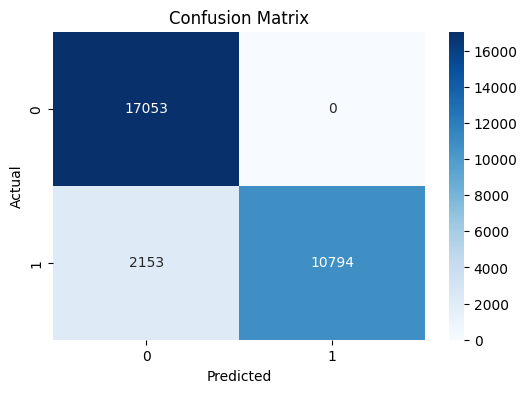

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png")

mlflow.log_artifact("confusion_matrix.png")

plt.show()

plt.close()

In [24]:
X.iloc[[0]].to_csv(
    "../data/processed/template_customer.csv",
    index=False
)

In [26]:
import joblib

joblib.dump(
    best_model,
    "../models/churn_model.pkl"
)

mlflow.sklearn.log_model(
    sk_model=best_model,
    name="model"
)

mlflow.end_run()

print("Model Saved Successfully.")

2026/06/26 13:44:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Model Saved Successfully.
